In [20]:
%pip install matplotlib
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 5.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 7.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 8.9 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 2.4/36.6 MB 11.5 MB/s eta 0:00:03
   ----- ---------------------------------- 4.7/36.6 MB 11.4 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/36.6 MB 11.5 MB/s eta 0:00:03
   ---------- ----------------------------- 9.4/36.6 MB 11.2 MB/s eta 0:00:03
   ------------ ---------------------

In [22]:
# NumPy: numerical operations and random sampling.
import numpy as np

# Pandas: loading and manipulating tabular data.
import pandas as pd

# Matplotlib: plotting distributions and learning curves.
import matplotlib.pyplot as plt

# Path: operating-system-independent file paths.
from pathlib import Path

# Scikit-learn: preprocessing, train/test splitting, and evaluation.
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

# Reproducibility: the same seed gives repeatable random experiments.
SEED = 42
rng = np.random.default_rng(SEED)

# Dataset location relative to the notebook.
DATA_DIR = Path("data") / "ml-1m"

print("Imports successful.")
print("Dataset directory:", DATA_DIR)

Imports successful.
Dataset directory: data\ml-1m


In [23]:
data_dir = Path("data/ml-1m")

users = pd.read_csv(
    data_dir / "users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

movies = pd.read_csv(
    data_dir / "movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)

ratings = pd.read_csv(
    data_dir / "ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print("Users:", users.shape)
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Users: (6040, 5)
Movies: (3883, 3)
Ratings: (1000209, 4)


In [24]:
# Display a few rows from each table to verify parsing.
display(users.head())
display(movies.head())
display(ratings.head())

# Check for missing values.
print("Missing values in users:")
print(users.isna().sum())

print("\nMissing values in movies:")
print(movies.isna().sum())

print("\nMissing values in ratings:")
print(ratings.isna().sum())

# Check the rating scale.
print("\nRating distribution:")
print(ratings["rating"].value_counts().sort_index())

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Missing values in users:
user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64

Missing values in movies:
movie_id    0
title       0
genres      0
dtype: int64

Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Rating distribution:
rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


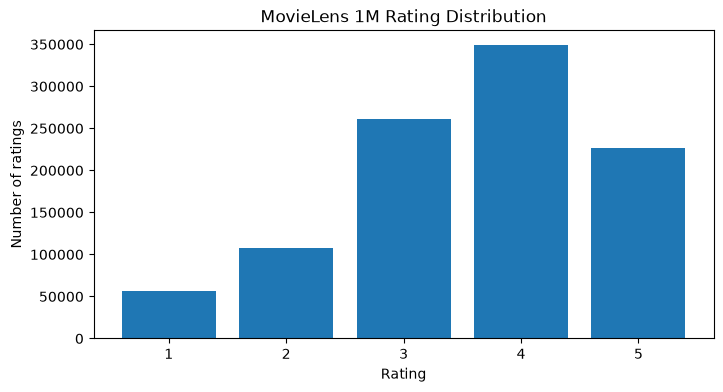

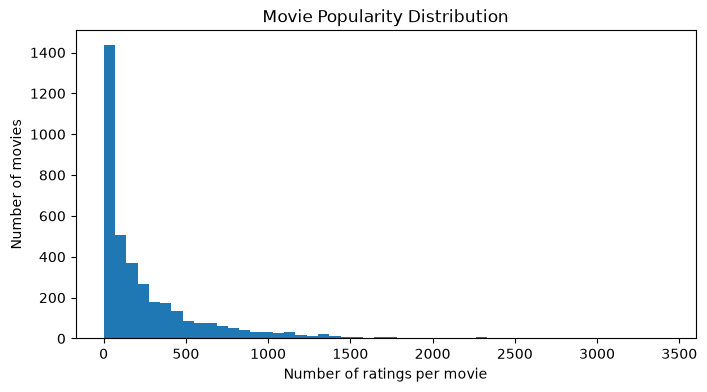

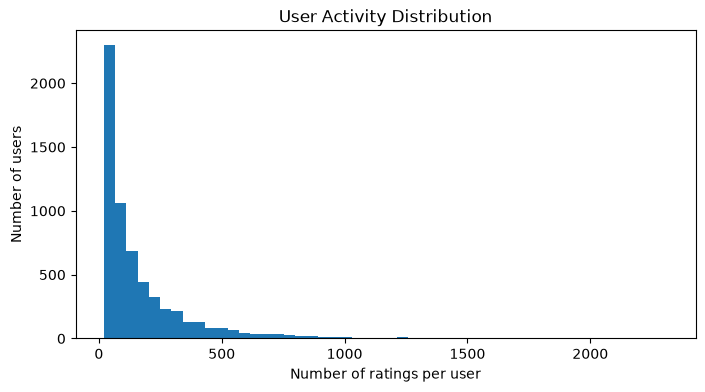

In [25]:
# Plot how many ratings each score receives.
rating_counts = ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("MovieLens 1M Rating Distribution")
plt.xticks(rating_counts.index)
plt.show()

# Count how many ratings each movie has.
movie_activity = ratings.groupby("movie_id").size()

plt.figure(figsize=(8, 4))
plt.hist(movie_activity, bins=50)
plt.xlabel("Number of ratings per movie")
plt.ylabel("Number of movies")
plt.title("Movie Popularity Distribution")
plt.show()

# Count how many ratings each user has.
user_activity = ratings.groupby("user_id").size()

plt.figure(figsize=(8, 4))
plt.hist(user_activity, bins=50)
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("User Activity Distribution")
plt.show()

In [26]:
# Split the genre strings into individual genres.
# MovieLens uses "|" between genres.
movies["genre_list"] = movies["genres"].str.split("|")

# Collect all unique genres in the dataset.
all_genres = sorted({
    genre
    for genre_list in movies["genre_list"]
    for genre in genre_list
})

print("Number of genres:", len(all_genres))
print(all_genres)

# Create a binary feature column for each genre.
for genre in all_genres:
    movies[f"genre_{genre}"] = movies["genre_list"].apply(
        lambda genre_list: int(genre in genre_list)
    )

# View the resulting feature matrix.
genre_columns = [f"genre_{genre}" for genre in all_genres]

display(movies[["movie_id", "title"] + genre_columns].head())

Number of genres: 18
['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,movie_id,title,genre_Action,genre_Adventure,genre_Animation,genre_Children's,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
# Convert gender into a numeric feature.
# This is a dataset attribute, not a statement about a user's identity.
users["gender_encoded"] = users["gender"].map({"M": 0, "F": 1})

# One-hot encode age groups and occupations.
# Drop the first category to avoid redundant columns.
user_features = pd.get_dummies(
    users[["user_id", "age", "occupation"]],
    columns=["age", "occupation"],
    drop_first=True,
    dtype=float
)

# Add the encoded gender.
user_features["gender_encoded"] = users["gender_encoded"].astype(float)

print("User feature matrix:", user_features.shape)
display(user_features.head())

User feature matrix: (6040, 28)


,user_id,age_18,age_25,age_35,age_45,age_50,age_56,occupation_1,occupation_2,occupation_3,...,occupation_12,occupation_13,occupation_14,occupation_15,occupation_16,occupation_17,occupation_18,occupation_19,occupation_20,gender_encoded
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [28]:
# Sort interactions chronologically.
ratings_sorted = ratings.sort_values("timestamp").reset_index(drop=True)

# Use the earliest 80% for constructing the initial training history.
split_index = int(len(ratings_sorted) * 0.80)

train_ratings = ratings_sorted.iloc[:split_index].copy()
test_ratings = ratings_sorted.iloc[split_index:].copy()

print("Training interactions:", train_ratings.shape)
print("Testing interactions:", test_ratings.shape)

print("\nTraining time range:")
print(train_ratings["timestamp"].min(), "to", train_ratings["timestamp"].max())

print("\nTesting time range:")
print(test_ratings["timestamp"].min(), "to", test_ratings["timestamp"].max())

Training interactions: (800167, 4)
Testing interactions: (200042, 4)

Training time range:
956703932 to 975768738

Testing time range:
975768738 to 1046454590


In [29]:
# Keep only the numeric user-feature columns.
user_feature_columns = [
    column for column in user_features.columns
    if column != "user_id"
]

# Select the movie genre features.
movie_feature_columns = genre_columns

# Number of features in each component.
n_user_features = len(user_feature_columns)
n_movie_features = len(movie_feature_columns)

# Total context dimension.
CONTEXT_DIM = n_user_features + n_movie_features

print("User feature dimension:", n_user_features)
print("Movie feature dimension:", n_movie_features)
print("Total context dimension:", CONTEXT_DIM)

User feature dimension: 27
Movie feature dimension: 18
Total context dimension: 45


In [30]:
# Map each user ID to its numerical feature vector.
user_feature_lookup = (
    user_features
    .set_index("user_id")[user_feature_columns]
    .to_dict("index")
)

# Map each movie ID to its numerical genre vector.
movie_feature_lookup = (
    movies
    .set_index("movie_id")[movie_feature_columns]
    .to_dict("index")
)

# Convert lookup values to NumPy arrays for efficient computation.
user_feature_lookup = {
    user_id: np.asarray(list(features.values()), dtype=np.float64)
    for user_id, features in user_feature_lookup.items()
}

movie_feature_lookup = {
    movie_id: np.asarray(list(features.values()), dtype=np.float64)
    for movie_id, features in movie_feature_lookup.items()
}

# Example: inspect one user and one movie.
example_user_id = users["user_id"].iloc[0]
example_movie_id = movies["movie_id"].iloc[0]

print("Example user vector:", user_feature_lookup[example_user_id])
print("Example movie vector:", movie_feature_lookup[example_movie_id])

Example user vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1.]
Example movie vector: [0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [31]:
def make_context(user_id, movie_id):
    """
    Construct the context vector for a user–movie pair.

    The vector concatenates:
    1. User demographic features.
    2. Movie genre features.

    Returns:
        NumPy array of shape (CONTEXT_DIM,).
    """
    user_vector = user_feature_lookup[user_id]
    movie_vector = movie_feature_lookup[movie_id]

    return np.concatenate([user_vector, movie_vector])


# Test the function.
x_example = make_context(example_user_id, example_movie_id)

print("Context shape:", x_example.shape)
print("Expected shape:", (CONTEXT_DIM,))

Context shape: (45,)
Expected shape: (45,)


In [32]:
# Fit a scaler using the training users and movies.
# Scaling helps numerical stability in linear models.
#
# We create a sample of contexts from observed training interactions.
# This avoids constructing an enormous full user × movie matrix.

scaler_sample_size = min(100_000, len(train_ratings))

scaler_sample = train_ratings.sample(
    n=scaler_sample_size,
    random_state=SEED
)

X_scaler = np.vstack([
    make_context(row.user_id, row.movie_id)
    for row in scaler_sample.itertuples(index=False)
])

context_scaler = StandardScaler()
context_scaler.fit(X_scaler)

print("Context scaler fitted.")
print("Scaler input shape:", X_scaler.shape)

Context scaler fitted.
Scaler input shape: (100000, 45)


In [33]:
# Define the threshold for a positive recommendation response.
POSITIVE_RATING_THRESHOLD = 4

# Add a binary reward column.
train_ratings["reward"] = (
    train_ratings["rating"] >= POSITIVE_RATING_THRESHOLD
).astype(int)

test_ratings["reward"] = (
    test_ratings["rating"] >= POSITIVE_RATING_THRESHOLD
).astype(int)

print("Training positive-response rate:",
      train_ratings["reward"].mean())

print("Testing positive-response rate:",
      test_ratings["reward"].mean())

Training positive-response rate: 0.5786542059345112
Testing positive-response rate: 0.5611871506983533


In [34]:
# Count ratings per movie in the training data.
movie_counts = train_ratings["movie_id"].value_counts()

# Use the most frequently rated movies as the initial candidate set.
# This reduces computation and ensures sufficient historical coverage.
N_CANDIDATES = 100

candidate_movie_ids = (
    movie_counts
    .head(N_CANDIDATES)
    .index
    .to_numpy()
)

print("Number of candidate movies:", len(candidate_movie_ids))
print("Candidate movie IDs:", candidate_movie_ids[:10])

Number of candidate movies: 100
Candidate movie IDs: [2858  260 1196 1210  589 2028  480 1270 2571 1580]


In [35]:
# Use a fixed sample of test interactions for the first experiment.
# Each row supplies a user and a held-out movie rating.
#
# We will evaluate the policy's selected movie against the
# historical reward of that selected movie.

EVAL_INTERACTIONS = min(20_000, len(test_ratings))

evaluation_data = test_ratings.sample(
    n=EVAL_INTERACTIONS,
    random_state=SEED
).reset_index(drop=True)

print("Evaluation interactions:", len(evaluation_data))
display(evaluation_data.head())

Evaluation interactions: 20000


,user_id,movie_id,rating,timestamp,reward
0,368,1729,5,976312364,1
1,2380,2683,5,1027968893,1
2,1733,3503,4,1038104643,1
3,516,2454,3,976280793,0
4,3610,169,1,977632923,0


In [36]:
# Create a lookup for held-out ratings.
# Duplicate user–movie pairs are aggregated using their maximum rating.
# This gives the oracle a single deterministic reward per pair.

test_reward_lookup = (
    test_ratings
    .groupby(["user_id", "movie_id"])["reward"]
    .max()
    .to_dict()
)

def historical_reward(user_id, movie_id):
    """
    Return the held-out binary reward for a user–movie pair.

    If the pair has no observed held-out rating, return None.
    This means the offline dataset does not directly reveal
    the user's response to that recommended movie.
    """
    return test_reward_lookup.get((user_id, movie_id), None)


# Example lookup.
example_pair = evaluation_data.iloc[0]

print(
    "Example historical reward:",
    historical_reward(example_pair.user_id, example_pair.movie_id)
)

Example historical reward: 1


In [37]:
class BasePolicy:
    """
    Base class for recommendation policies.

    Each policy must implement:
    - select_action: choose a movie using the current context.
    - update: learn from the observed reward.
    """

    def select_action(self, user_id, candidate_movie_ids):
        raise NotImplementedError

    def update(self, user_id, movie_id, reward):
        raise NotImplementedError

In [38]:
class RandomPolicy(BasePolicy):
    """
    Selects a movie uniformly at random.

    This provides a simple baseline for evaluating whether
    learning-based policies actually improve recommendation quality.
    """

    def __init__(self, seed=SEED):
        self.rng = np.random.default_rng(seed)

    def select_action(self, user_id, candidate_movie_ids):
        return int(self.rng.choice(candidate_movie_ids))

    def update(self, user_id, movie_id, reward):
        # Random policy does not learn from feedback.
        pass

In [39]:
class EpsilonGreedyPolicy(BasePolicy):
    """
    Linear contextual ε-greedy policy.

    With probability epsilon:
        Explore by choosing a random movie.

    Otherwise:
        Exploit by choosing the movie with the highest predicted reward.

    The reward model is learned using stochastic gradient descent.
    """

    def __init__(self, context_dim, epsilon=0.10, learning_rate=0.01):
        self.context_dim = context_dim
        self.epsilon = epsilon
        self.learning_rate = learning_rate

        # Linear reward model: predicted reward = x @ theta.
        self.theta = np.zeros(context_dim, dtype=np.float64)

    def predict(self, context):
        return float(context @ self.theta)

    def select_action(self, user_id, candidate_movie_ids):
        # Explore: random recommendation.
        if rng.random() < self.epsilon:
            return int(rng.choice(candidate_movie_ids))

        # Exploit: select the candidate with the highest prediction.
        scores = [
            self.predict(
                context_scaler.transform(
                    make_context(user_id, movie_id).reshape(1, -1)
                )[0]
            )
            for movie_id in candidate_movie_ids
        ]

        return int(candidate_movie_ids[np.argmax(scores)])

    def update(self, user_id, movie_id, reward):
        # Compute the standardized context.
        context = context_scaler.transform(
            make_context(user_id, movie_id).reshape(1, -1)
        )[0]

        # Prediction error.
        prediction = self.predict(context)
        error = reward - prediction

        # SGD update for squared error loss.
        self.theta += self.learning_rate * error * context

In [40]:
class LinUCBPolicy(BasePolicy):
    """
    Linear Upper Confidence Bound (LinUCB).

    A tracks the feature covariance matrix.
    b tracks the reward-weighted feature vectors.

    The model estimates:
        theta = A^{-1} b

    The action score combines:
        predicted reward + uncertainty bonus.
    """

    def __init__(self, context_dim, alpha=1.0, l2_reg=1.0):
        self.context_dim = context_dim
        self.alpha = alpha
        self.l2_reg = l2_reg

        # Regularized covariance matrix.
        self.A = l2_reg * np.eye(context_dim)

        # Reward-weighted feature vector.
        self.b = np.zeros(context_dim)

    def _theta(self):
        # Solve A theta = b instead of explicitly computing A inverse.
        return np.linalg.solve(self.A, self.b)

    def score(self, context):
        theta = self._theta()

        # Estimated mean reward.
        mean = context @ theta

        # Uncertainty term.
        uncertainty = np.sqrt(
            context @ np.linalg.solve(self.A, context)
        )

        return float(mean + self.alpha * uncertainty)

    def select_action(self, user_id, candidate_movie_ids):
        scores = []

        for movie_id in candidate_movie_ids:
            context = context_scaler.transform(
                make_context(user_id, movie_id).reshape(1, -1)
            )[0]

            scores.append(self.score(context))

        return int(candidate_movie_ids[np.argmax(scores)])

    def update(self, user_id, movie_id, reward):
        context = context_scaler.transform(
            make_context(user_id, movie_id).reshape(1, -1)
        )[0]

        # Bayesian-style linear regression update.
        self.A += np.outer(context, context)
        self.b += reward * context

In [41]:
# Build candidate movies for each evaluation user.
# Only include movies that appear in the held-out evaluation data
# and belong to our candidate movie pool.

candidate_set = set(candidate_movie_ids)

user_candidate_lookup = {}

for user_id, group in evaluation_data.groupby("user_id"):
    available_movies = [
        movie_id
        for movie_id in group["movie_id"].unique()
        if movie_id in candidate_set
    ]

    if available_movies:
        user_candidate_lookup[user_id] = np.array(
            available_movies,
            dtype=int
        )

print("Users with eligible candidate movies:",
      len(user_candidate_lookup))

Users with eligible candidate movies: 1065


In [42]:
# Initialize separate policies.
random_policy = RandomPolicy(seed=SEED)

epsilon_policy = EpsilonGreedyPolicy(
    context_dim=CONTEXT_DIM,
    epsilon=0.10,
    learning_rate=0.01
)

linucb_policy = LinUCBPolicy(
    context_dim=CONTEXT_DIM,
    alpha=1.0,
    l2_reg=1.0
)

# Training interactions are historical observations.
# The policies learn from the reward associated with each observed pair.
for row in train_ratings.itertuples(index=False):
    user_id = row.user_id
    movie_id = row.movie_id
    reward = row.reward

    epsilon_policy.update(user_id, movie_id, reward)
    linucb_policy.update(user_id, movie_id, reward)

print("Training completed.")

C:\Users\AGNIVESH CHATTERJEE\AppData\Local\Temp\ipykernel_20172\1222780358.py:23: RuntimeWarning: overflow encountered in matmul
  return float(context @ self.theta)
C:\Users\AGNIVESH CHATTERJEE\AppData\Local\Temp\ipykernel_20172\1222780358.py:23: RuntimeWarning: invalid value encountered in matmul
  return float(context @ self.theta)


Training completed.


In [43]:
def evaluate_policy(policy, evaluation_data, user_candidate_lookup):
    """
    Evaluate a policy using observed held-out rewards.

    For each evaluation interaction:
    1. Retrieve the user's eligible candidate movies.
    2. Let the policy choose one movie.
    3. Look up the held-out reward for that selected movie.
    4. Record whether the policy received a positive reward.

    This evaluation is limited to observed candidate feedback.
    """

    results = []

    for row in evaluation_data.itertuples(index=False):
        user_id = row.user_id

        # Skip users without eligible candidate movies.
        if user_id not in user_candidate_lookup:
            continue

        candidates = user_candidate_lookup[user_id]

        selected_movie = policy.select_action(
            user_id,
            candidates
        )

        reward = historical_reward(user_id, selected_movie)

        # If the selected movie has no observed held-out reward,
        # it cannot be evaluated using this offline oracle.
        if reward is None:
            continue

        results.append({
            "user_id": user_id,
            "selected_movie": selected_movie,
            "reward": reward
        })

    return pd.DataFrame(results)

In [44]:
# Evaluate each policy independently.
# The policies are already trained using the training interactions.

random_results = evaluate_policy(
    random_policy,
    evaluation_data,
    user_candidate_lookup
)

epsilon_results = evaluate_policy(
    epsilon_policy,
    evaluation_data,
    user_candidate_lookup
)

linucb_results = evaluate_policy(
    linucb_policy,
    evaluation_data,
    user_candidate_lookup
)

print("Random evaluated interactions:", len(random_results))
print("Epsilon-greedy evaluated interactions:", len(epsilon_results))
print("LinUCB evaluated interactions:", len(linucb_results))

Random evaluated interactions: 17525
Epsilon-greedy evaluated interactions: 17525
LinUCB evaluated interactions: 17525


In [45]:
# Average reward is the fraction of evaluated recommendations
# that received a positive held-out rating.

policy_results = {
    "Random": random_results,
    "Epsilon-Greedy": epsilon_results,
    "LinUCB": linucb_results
}

summary_rows = []

for policy_name, results in policy_results.items():
    summary_rows.append({
        "Policy": policy_name,
        "Evaluated interactions": len(results),
        "Average reward": results["reward"].mean()
            if len(results) > 0 else np.nan
    })

summary = pd.DataFrame(summary_rows)

display(summary)

,Policy,Evaluated interactions,Average reward
0,Random,17525,0.727019
1,Epsilon-Greedy,17525,0.725193
2,LinUCB,17525,0.750014


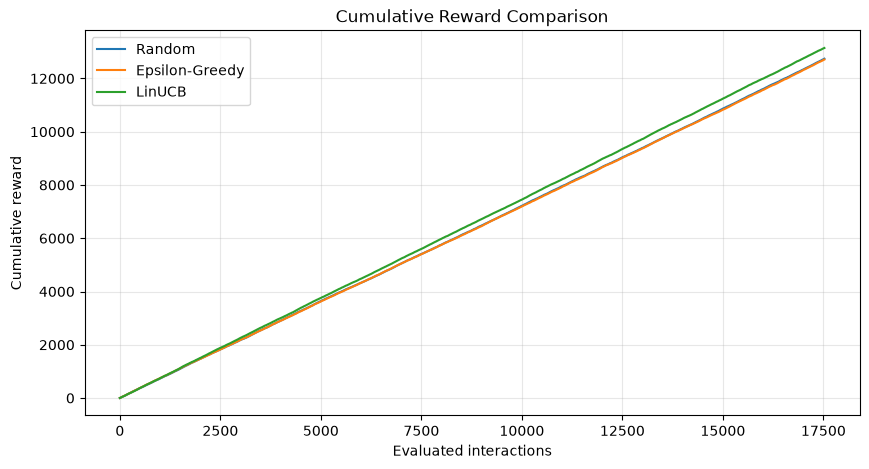

In [46]:
def cumulative_reward_curve(results):
    """
    Calculate cumulative reward over the evaluation sequence.
    """
    if len(results) == 0:
        return np.array([])

    return results["reward"].to_numpy().cumsum()


# Compute cumulative reward curves.
random_cumulative = cumulative_reward_curve(random_results)
epsilon_cumulative = cumulative_reward_curve(epsilon_results)
linucb_cumulative = cumulative_reward_curve(linucb_results)

# Plot the curves.
plt.figure(figsize=(10, 5))

plt.plot(random_cumulative, label="Random")
plt.plot(epsilon_cumulative, label="Epsilon-Greedy")
plt.plot(linucb_cumulative, label="LinUCB")

plt.xlabel("Evaluated interactions")
plt.ylabel("Cumulative reward")
plt.title("Cumulative Reward Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
def build_observed_best_reward_lookup(evaluation_data, user_candidate_lookup):
    """
    For each user, find the maximum observed reward among
    the eligible candidate movies in the evaluation data.
    """

    best_reward_lookup = {}

    for user_id, candidates in user_candidate_lookup.items():
        observed_rewards = [
            historical_reward(user_id, movie_id)
            for movie_id in candidates
        ]

        # Ignore missing observations.
        observed_rewards = [
            reward for reward in observed_rewards
            if reward is not None
        ]

        if observed_rewards:
            best_reward_lookup[user_id] = max(observed_rewards)

    return best_reward_lookup


best_reward_lookup = build_observed_best_reward_lookup(
    evaluation_data,
    user_candidate_lookup
)

print("Users with observed best rewards:",
      len(best_reward_lookup))

Users with observed best rewards: 1065


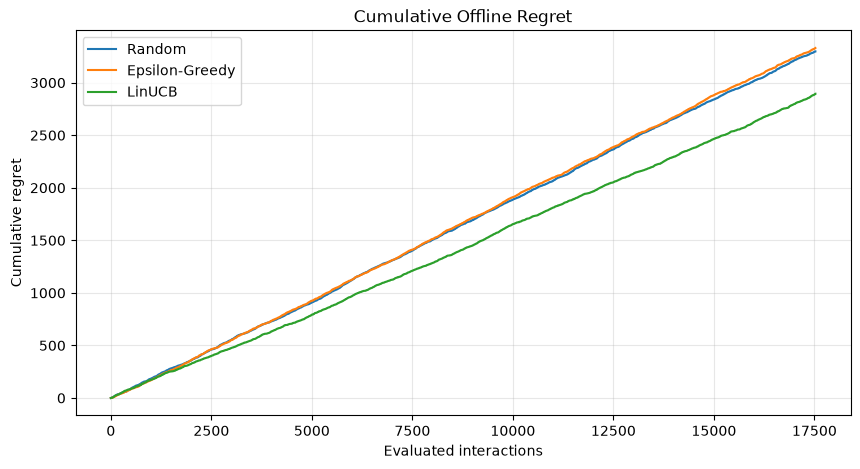

In [48]:
def calculate_regret(results, best_reward_lookup):
    """
    Calculate cumulative regret relative to the best observed
    reward available for each evaluated user's candidate set.
    """

    regrets = []

    for row in results.itertuples(index=False):
        user_id = row.user_id
        reward = row.reward

        if user_id not in best_reward_lookup:
            continue

        best_reward = best_reward_lookup[user_id]

        # Instantaneous regret.
        regrets.append(best_reward - reward)

    return np.cumsum(regrets)


random_regret = calculate_regret(
    random_results,
    best_reward_lookup
)

epsilon_regret = calculate_regret(
    epsilon_results,
    best_reward_lookup
)

linucb_regret = calculate_regret(
    linucb_results,
    best_reward_lookup
)

plt.figure(figsize=(10, 5))

plt.plot(random_regret, label="Random")
plt.plot(epsilon_regret, label="Epsilon-Greedy")
plt.plot(linucb_regret, label="LinUCB")

plt.xlabel("Evaluated interactions")
plt.ylabel("Cumulative regret")
plt.title("Cumulative Offline Regret")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
# Calculate summary statistics for each policy.
# CTR here means the fraction of evaluated recommendations
# that corresponded to positive held-out ratings.

comparison = []

for policy_name, results in policy_results.items():
    if len(results) == 0:
        continue

    comparison.append({
        "Policy": policy_name,
        "Evaluated interactions": len(results),
        "Mean reward": results["reward"].mean(),
        "Positive responses": results["reward"].sum()
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Policy,Evaluated interactions,Mean reward,Positive responses
0,Random,17525,0.727019,12741
1,Epsilon-Greedy,17525,0.725193,12709
2,LinUCB,17525,0.750014,13144


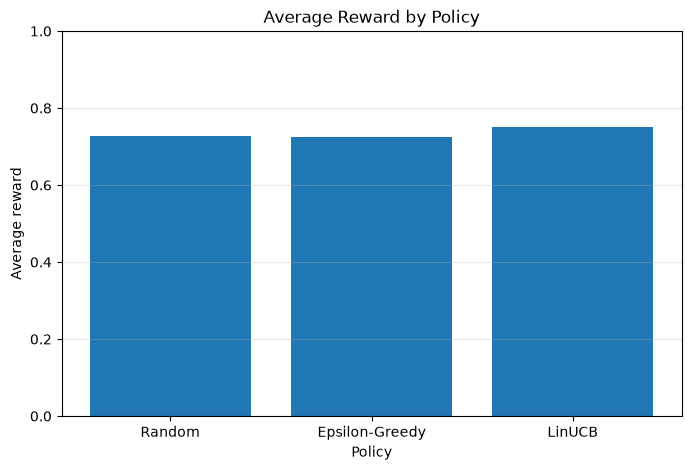

In [50]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Policy"],
    comparison_df["Mean reward"]
)

plt.xlabel("Policy")
plt.ylabel("Average reward")
plt.title("Average Reward by Policy")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [51]:
# Count how often each policy selected a movie.
# This helps us understand whether a policy over-recommends
# a small number of popular movies.

for policy_name, results in policy_results.items():
    print(f"\nTop recommendations — {policy_name}")

    top_movies = results["selected_movie"].value_counts().head(10)

    display(
        top_movies.rename("recommendation_count").to_frame()
    )


Top recommendations — Random


,recommendation_count
selected_movie,
3578,376
2762,338
648,331
2858,297
1196,296
1270,274
260,273
1198,269
2396,269



Top recommendations — Epsilon-Greedy


,recommendation_count
selected_movie,
3578,431
1923,394
648,360
1196,329
2028,328
1210,314
2997,312
1387,291
2858,273



Top recommendations — LinUCB


,recommendation_count
selected_movie,
2028,985
1617,863
2987,825
527,716
1213,621
1196,602
110,599
608,580
541,548


In [52]:
# Save the learned LinUCB parameters so we can recover the model
# without retraining it from the beginning.

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

np.savez(
    MODEL_DIR / "linucb_movielens_1m.npz",
    A=linucb_policy.A,
    b=linucb_policy.b,
    alpha=linucb_policy.alpha,
    l2_reg=linucb_policy.l2_reg
)

print("LinUCB model saved to:", MODEL_DIR / "linucb_movielens_1m.npz")

LinUCB model saved to: models\linucb_movielens_1m.npz


In [53]:
# Reconstruct the policy using the saved parameters.

saved_model = np.load(
    MODEL_DIR / "linucb_movielens_1m.npz"
)

recovered_linucb = LinUCBPolicy(
    context_dim=CONTEXT_DIM,
    alpha=float(saved_model["alpha"]),
    l2_reg=float(saved_model["l2_reg"])
)

recovered_linucb.A = saved_model["A"]
recovered_linucb.b = saved_model["b"]

print("Model recovered successfully.")

Model recovered successfully.
